In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


2026-01-07 17:17:18.574826: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 17:17:19.184500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 17:17:21.461424: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
BASE_DIR = Path("/mnt/c/Users/AbdulHafeez/Brain_Tumor/dataset_split")

train_dir = BASE_DIR / "train"
val_dir   = BASE_DIR / "val"
test_dir  = BASE_DIR / "test"

print(train_dir.exists(), val_dir.exists(), test_dir.exists())


True True True


In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4


In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [7]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse"
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)


Found 7390 images belonging to 4 classes.
Found 1582 images belonging to 4 classes.
Found 1588 images belonging to 4 classes.


In [8]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False   # FREEZE base model


I0000 00:00:1767806263.831030     645 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1753 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)   # regularization
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [11]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [23]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
147/231 ━━━━━━━━━━━━━━━━━━━━ 31s 374ms/step - accuracy: 0.5457 - loss: 1.0311

2025-12-27 12:51:56.019048: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-27 12:51:56.198060: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-27 12:51:57.105181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-27 12:51:57.328242: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-27 12:51:57.533778: E external/local_xla/xla/stream_

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.5961 - loss: 0.9405

2025-12-27 12:52:39.844701: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng46{k2=5,k5=3,k14=4} for conv (f32[14,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,3,225,225]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-12-27 12:52:39.845769: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.91124932s
Trying algorithm eng46{k2=5,k5=3,k14=4} for conv (f32[14,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,3,225,225]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={

231/231 ━━━━━━━━━━━━━━━━━━━━ 130s 520ms/step - accuracy: 0.5966 - loss: 0.9397 - val_accuracy: 0.8034 - val_loss: 0.5110
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 70s 304ms/step - accuracy: 0.7761 - loss: 0.5607 - val_accuracy: 0.8375 - val_loss: 0.4166
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 79s 343ms/step - accuracy: 0.8174 - loss: 0.4754 - val_accuracy: 0.8451 - val_loss: 0.3928
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 62s 270ms/step - accuracy: 0.8170 - loss: 0.4642 - val_accuracy: 0.8534 - val_loss: 0.3800
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 74s 320ms/step - accuracy: 0.8361 - loss: 0.4280 - val_accuracy: 0.8692 - val_loss: 0.3514
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 69s 297ms/step - accuracy: 0.8299 - loss: 0.4316 - val_accuracy: 0.8565 - val_loss: 0.3550
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 64s 277ms/step - accuracy: 0.8410 - loss: 0.4147 - val_accuracy: 0.8729 - val_loss: 0.3359
Epoch 8/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 65s 281ms/step - accuracy: 0.8393 - loss: 0.4225 - va

In [24]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8362 - loss: 0.3945
Test Accuracy: 0.8539
Test Loss: 0.3610


50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.87      0.86      0.86       564
  meningioma       0.78      0.63      0.70       352
    no_tumor       0.93      0.94      0.94       265
   pituitary       0.84      0.98      0.91       407

    accuracy                           0.85      1588
   macro avg       0.85      0.85      0.85      1588
weighted avg       0.85      0.85      0.85      1588



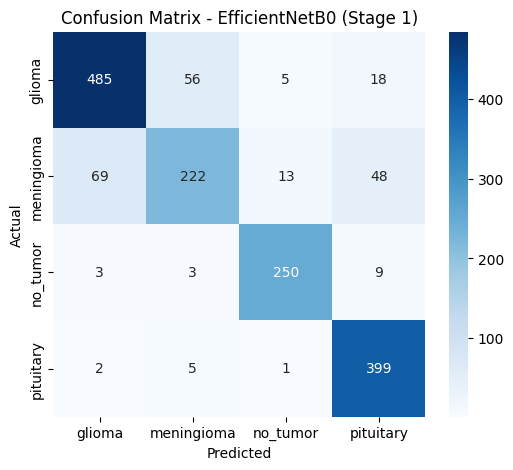

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0 (Stage 1)")
plt.show()


In [27]:
FINE_TUNE_AT = len(base_model.layers) - 30


In [28]:
for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True


In [29]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [30]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    ),
    ModelCheckpoint(
        "efficientnet_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [31]:
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)


Epoch 1/15


2025-12-27 13:09:06.521831: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-27 13:09:06.717713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


231/231 ━━━━━━━━━━━━━━━━━━━━ 98s 343ms/step - accuracy: 0.7029 - loss: 0.7915 - val_accuracy: 0.8515 - val_loss: 0.3909 - learning_rate: 1.0000e-05
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 65s 279ms/step - accuracy: 0.7980 - loss: 0.5292 - val_accuracy: 0.8565 - val_loss: 0.3701 - learning_rate: 1.0000e-05
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 61s 264ms/step - accuracy: 0.8211 - loss: 0.4639 - val_accuracy: 0.8704 - val_loss: 0.3380 - learning_rate: 1.0000e-05
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 66s 286ms/step - accuracy: 0.8334 - loss: 0.4294 - val_accuracy: 0.8786 - val_loss: 0.3160 - learning_rate: 1.0000e-05
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 66s 285ms/step - accuracy: 0.8458 - loss: 0.4044 - val_accuracy: 0.8875 - val_loss: 0.3005 - learning_rate: 1.0000e-05
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 65s 280ms/step - accuracy: 0.8433 - loss: 0.3919 - val_accuracy: 0.8875 - val_loss: 0.2923 - learning_rate: 1.0000e-05
Epoch 7/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 61s 262ms/step - 

In [32]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Stage-2 Test Accuracy: {test_acc:.4f}")
print(f"Stage-2 Test Loss: {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.8967 - loss: 0.2576
Stage-2 Test Accuracy: 0.9074
Stage-2 Test Loss: 0.2421


50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 186ms/step
Stage-2 Classification Report:
              precision    recall  f1-score   support

      glioma       0.92      0.90      0.91       564
  meningioma       0.84      0.79      0.82       352
    no_tumor       0.96      0.96      0.96       265
   pituitary       0.91      0.99      0.94       407

    accuracy                           0.91      1588
   macro avg       0.91      0.91      0.91      1588
weighted avg       0.91      0.91      0.91      1588



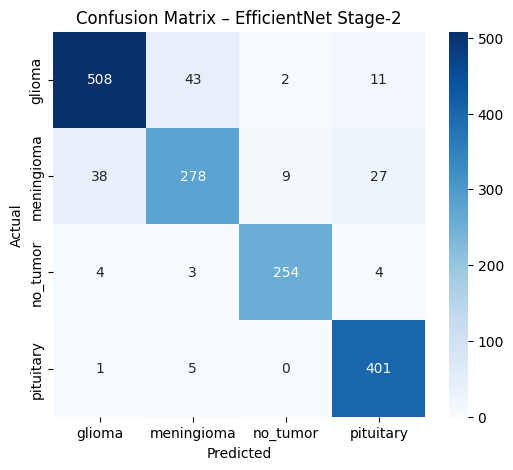

In [33]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Stage-2 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – EfficientNet Stage-2")
plt.show()


In [12]:
FINE_TUNE_AT = len(base_model.layers) - 50

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True



In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_stage3 = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "brain_tumor_efficientnet_stage3.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]


In [15]:
history_stage3 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks_stage3
)


/home/abdulhafeez/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8


2026-01-07 17:18:46.160219: I external/local_xla/xla/service/service.cc:163] XLA service 0x797d54002240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-07 17:18:46.160248: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-01-07 17:18:46.485052: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-07 17:18:48.163902: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-01-07 17:18:56.240559: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng53{k2=1,k13=0,k14=3,k18=0,k23=0} for conv (f32[32,32,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,225,225]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}), window={size=3x3 stride=2x2}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

173/231 ━━━━━━━━━━━━━━━━━━━━ 17s 294ms/step - accuracy: 0.3719 - loss: 1.3514

2026-01-07 17:20:11.380203: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[30,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[30,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-01-07 17:20:05.968113: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 484.234229ms
Trying algorithm eng3{k11=2} for conv (f32[30,480,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[30,480,14,14]{3,2,1,0}, f32[480,1,3,3]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, feature_group_count=480, custom_call_target="__cudnn

231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.3884 - loss: 1.3300

2026-01-07 17:20:54.610837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 17:20:54.838588: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 17:21:01.469616: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng3{k11=2} for conv (f32[14,1152,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,1152,7,7]{3,2,1,0}, f32[1152,1,5,5]{3,2,1,0}), window={size=5x5 pad=2_2x2_2}, dim_labels=bf01_oi01->bf01, feature_group_count=1152, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"le

231/231 ━━━━━━━━━━━━━━━━━━━━ 142s 481ms/step - accuracy: 0.3887 - loss: 1.3297 - val_accuracy: 0.6403 - val_loss: 1.0185 - learning_rate: 5.0000e-06
Epoch 2/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 63s 273ms/step - accuracy: 0.6029 - loss: 1.0508 - val_accuracy: 0.7181 - val_loss: 0.8170 - learning_rate: 5.0000e-06
Epoch 3/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 66s 284ms/step - accuracy: 0.6826 - loss: 0.8913 - val_accuracy: 0.7560 - val_loss: 0.6862 - learning_rate: 5.0000e-06
Epoch 4/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 67s 292ms/step - accuracy: 0.7152 - loss: 0.7856 - val_accuracy: 0.7737 - val_loss: 0.5981 - learning_rate: 5.0000e-06
Epoch 5/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 66s 287ms/step - accuracy: 0.7489 - loss: 0.6917 - val_accuracy: 0.7914 - val_loss: 0.5326 - learning_rate: 5.0000e-06
Epoch 6/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 67s 291ms/step - accuracy: 0.7807 - loss: 0.6103 - val_accuracy: 0.8104 - val_loss: 0.4830 - learning_rate: 5.0000e-06
Epoch 7/8
231/231 ━━━━━━━━━━━━━━━━━━━━ 66s 285ms/step - accur

In [16]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Stage-3 Test Accuracy: {test_acc:.4f}")
print(f"Stage-3 Test Loss: {test_loss:.4f}")


49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8191 - loss: 0.4481

2026-01-07 17:30:04.103463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 17:30:04.320678: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 17:30:05.422795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 17:30:05.670933: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 17:30:12.194846: E external/local_xla/xla/service

50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 376ms/step - accuracy: 0.8193 - loss: 0.4478
Stage-3 Test Accuracy: 0.8237
Stage-3 Test Loss: 0.4395


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 173ms/step
Stage-3 Classification Report:
              precision    recall  f1-score   support

      glioma       0.84      0.87      0.85       564
  meningioma       0.74      0.54      0.62       352
    no_tumor       0.90      0.89      0.90       265
   pituitary       0.80      0.97      0.88       407

    accuracy                           0.82      1588
   macro avg       0.82      0.82      0.81      1588
weighted avg       0.82      0.82      0.82      1588



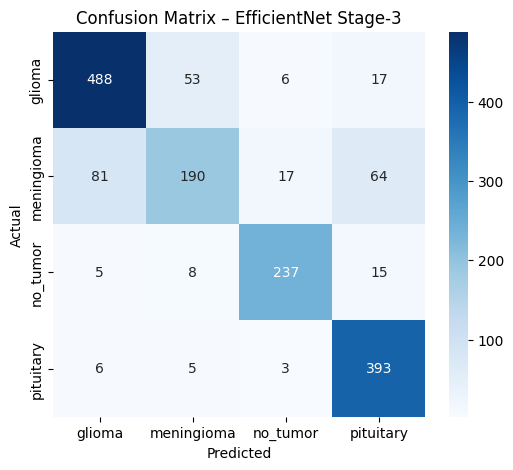

In [17]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("Stage-3 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – EfficientNet Stage-3")
plt.show()
